# First STDP experiment — does spike-timing-dependent plasticity differentiate correlated vs. uncorrelated input?

Per Jasper's message (relayed via Claude web chat, 2026-07-18). Direct test of the framework
doc's core unsupervised-plasticity claim: **does STDP alone, with zero global signal, learn
which inputs matter from spike-timing statistics alone?**

**Setup:** one postsynaptic LIF neuron (same `tau`, `v_rest`, `v_thresh`, `v_reset`, `t_ref`
validated in `brian2_install_check.ipynb`), driven by 20 presynaptic Poisson inputs through
STDP synapses, all starting at the same weight. 10 form a **correlated** group (share timing
structure with a common underlying process, individually jittered), 10 form an **uncorrelated**
group (fully independent Poisson). Both groups are **rate-matched** — same mean firing rate —
specifically so any weight differentiation found is attributable to timing correlation, not
just one group firing more overall. Standard exponential STDP kernel, `taupre=taupost=20ms`,
near-balanced but slightly depression-biased (`Apost = -Apre * taupre/taupost * 1.05`, standard
practice for stability). No labels, no loss, no backward pass — pure local STDP.

**Falsification criteria, stated before running anything:**
- **Real result:** weight distribution becomes bimodal by the end of the run — correlated
  group's weights drift up, uncorrelated group's drift down or stay near baseline. Reporting
  full distributions, not just means.
- **Failure mode 1 — runaway:** weights saturate to the ceiling (structurally the same shape
  as `w_char` lock-in from the Hopfield work — positive feedback: stronger synapse -> more
  reliable postsynaptic spike -> more potentiation). If this happens: report it as a real
  failure with a diagnosed cause, don't quietly cap-and-rerun.
- **Failure mode 2 — no differentiation:** weights stay clustered near initial value
  regardless of group. If this happens: root-cause (correlation strength too weak? STDP time
  constants mismatched to spike statistics?) before concluding STDP doesn't work here.

**Bounded pre-registered sweep, not open-ended tuning:** correlation strength `p_share` in
{0.3, 0.6, 0.9} (low/medium/high) x STDP rate `Apre` in {0.005, 0.02} (low/high) = 6 runs,
all reported regardless of outcome. No parameter adjustment outside this grid based on
results. One legitimate calibration step *is* done first: verifying the initial uniform
weight puts the postsynaptic neuron in a moderate, non-saturated firing regime before locking
in the grid — that's completing the pre-registration, not tuning the outcome.

In [1]:
from brian2 import *
import numpy as np
import matplotlib.pyplot as plt

prefs.codegen.target = 'cython'  # confirmed working in brian2_install_check.ipynb
seed(42)
np.random.seed(42)
print("Brian2", __import__('brian2').__version__)

Brian2 2.9.0


## Postsynaptic neuron — same validated LIF parameters, no tonic drive (input is purely synaptic now)

In [2]:
tau = 10*ms
v_rest = -70*mV
v_thresh = -50*mV
v_reset = -65*mV
t_ref = 5*ms

post_eqs = '''
dv/dt = (v_rest - v)/tau : volt (unless refractory)
'''

## Rate-matched spike train generation

Correlated group: each neuron's spike train = spikes copied from a shared "master" Poisson
process with probability `p_share` (jittered by a small Gaussian, so it's not literal
synchrony) **plus** independent background spikes filling in the remaining rate, so every
correlated neuron's *mean rate* stays equal to `target_rate` regardless of `p_share` — the
rate-matching control. Uncorrelated group: fully independent Poisson at the same
`target_rate`. All spike trains generated as explicit numpy arrays and fed through
`SpikeGeneratorGroup` for full reproducibility.

In [3]:
def poisson_times(rate_hz, duration_s, rng):
    n_expected = int(rate_hz * duration_s * 1.5) + 10
    isi = rng.exponential(1.0 / rate_hz, size=n_expected)
    times = np.cumsum(isi)
    return times[times < duration_s]

def dedup_spike_times(times, min_gap=0.0002):
    # SpikeGeneratorGroup requires no neuron spike twice within one dt (100us default) --
    # possible when combining shared+independent spike sources for the correlated group.
    if len(times) == 0:
        return times
    times = np.sort(times)
    keep = [times[0]]
    for t_val in times[1:]:
        if t_val - keep[-1] >= min_gap:
            keep.append(t_val)
    return np.array(keep)

def generate_correlated_group(n_neurons, target_rate_hz, p_share, duration_s, jitter_ms, rng):
    master_times = poisson_times(target_rate_hz, duration_s, rng)
    all_times, all_indices = [], []
    for i in range(n_neurons):
        keep = rng.random(len(master_times)) < p_share
        shared = master_times[keep] + rng.normal(0, jitter_ms / 1000.0, size=keep.sum())
        fill_rate = (1 - p_share) * target_rate_hz
        independent = poisson_times(fill_rate, duration_s, rng) if fill_rate > 0 else np.array([])
        combined = np.clip(np.concatenate([shared, independent]), 0, duration_s - 1e-6)
        combined = dedup_spike_times(combined)
        all_times.append(combined)
        all_indices.append(np.full(len(combined), i))
    return np.concatenate(all_indices), np.concatenate(all_times)

def generate_uncorrelated_group(n_neurons, target_rate_hz, duration_s, rng):
    all_times, all_indices = [], []
    for i in range(n_neurons):
        t = dedup_spike_times(poisson_times(target_rate_hz, duration_s, rng))
        all_times.append(t)
        all_indices.append(np.full(len(t), i))
    return np.concatenate(all_indices), np.concatenate(all_times)

def build_presynaptic_input(target_rate_hz, p_share, duration_s, rng, jitter_ms=2.0):
    corr_idx, corr_t = generate_correlated_group(10, target_rate_hz, p_share, duration_s, jitter_ms, rng)
    uncorr_idx, uncorr_t = generate_uncorrelated_group(10, target_rate_hz, duration_s, rng)
    uncorr_idx = uncorr_idx + 10  # indices 10-19
    all_idx = np.concatenate([corr_idx, uncorr_idx]).astype(int)
    all_t = np.concatenate([corr_t, uncorr_t])
    order = np.argsort(all_t)
    return all_idx[order], all_t[order] * second

# quick sanity check of the generator itself
rng_check = np.random.default_rng(0)
idx_check, t_check = build_presynaptic_input(20.0, 0.9, 10.0, rng_check)
rates_check = [np.sum(idx_check == i) / 10.0 for i in range(20)]
print(f"Rate check (target 20 Hz, p_share=0.9, 10s): corr group mean={np.mean(rates_check[:10]):.1f}Hz, "
      f"uncorr group mean={np.mean(rates_check[10:]):.1f}Hz -- should be close to each other and to 20Hz")

Rate check (target 20 Hz, p_share=0.9, 10s): corr group mean=17.7Hz, uncorr group mean=21.1Hz -- should be close to each other and to 20Hz


## STDP synapse model — standard canonical form (Brian2 tutorial pattern, well-tested)

Dimensionless weight `w` in `[0, wmax]`, scaled by `gmax` (voltage jump per unit weight) when
injecting into the postsynaptic neuron. Trace variables `apre`/`apost` implement the
exponential STDP kernel. `taupre=taupost=20ms` per spec. `Apost` set slightly larger in
magnitude than `Apre` (`*1.05`) — standard practice for stability (a very slight net
depression bias prevents unbounded drift even before the hard clip).

In [4]:
taupre = 20*ms
taupost = 20*ms
wmax = 1.0
gmax = 2*mV  # voltage jump at w=1; ~10-15 simultaneous full-weight synapses needed to cross threshold

stdp_model = '''
w : 1
dapre/dt = -apre/taupre : 1 (event-driven)
dapost/dt = -apost/taupost : 1 (event-driven)
'''
stdp_on_pre = '''
v_post += w*gmax
apre += Apre
w = clip(w+apost, 0, wmax)
'''
stdp_on_post = '''
apost += Apost
w = clip(w+apre, 0, wmax)
'''

## Calibration (allowed pre-registration step, not outcome-tuning): find a starting weight
that puts the postsynaptic neuron in a moderate, non-saturated firing regime

STDP frozen (weights fixed at `w_init` throughout), 20 independent-Poisson inputs at the
target rate (worst-case symmetric baseline, no correlation structure yet), checking the
resulting postsynaptic firing rate across a few candidate `w_init` values before locking in
the grid. "Moderate" target: roughly 1-15 Hz -- not silent, not saturating against the
refractory-period ceiling (which would be `1/t_ref = 200 Hz`).

In [5]:
TARGET_RATE = 20.0  # Hz, per presynaptic input
CALIB_DURATION = 10.0  # s

def run_calibration(w_init, gmax_val, duration_s, seed_val):
    start_scope()
    rng = np.random.default_rng(seed_val)
    idx, t = generate_uncorrelated_group(20, TARGET_RATE, duration_s, rng)
    order = np.argsort(t)
    idx, t = idx[order].astype(int), t[order] * second

    pre = SpikeGeneratorGroup(20, idx, t)
    post = NeuronGroup(1, post_eqs, threshold='v>v_thresh', reset='v=v_reset',
                        refractory=t_ref, method='exact')
    post.v = v_rest

    syn = Synapses(pre, post, model='w : 1', on_pre='v_post += w*gmax_val')
    syn.connect()
    syn.w = w_init

    mon = SpikeMonitor(post)
    run(duration_s*second)
    return mon.count[0] / duration_s

# gmax=2mV turned out far too small relative to the 20mV threshold gap given ~400Hz combined
# input rate (mean depolarization ~ rate*gmax*w*tau is only a few mV) -- widening the
# calibration grid to include gmax, not just w_init, since gmax is the parameter that's
# actually off. Still a calibration/setup step, not touching the real sweep grid (p_share, Apre).
print(f"{'gmax(mV)':>10} {'w_init':>8} {'rate(Hz)':>10}")
for gmax_candidate_mV in [5, 6, 6.5, 7]:
    for w_init_candidate in [0.5]:
        rate = run_calibration(w_init_candidate, gmax_candidate_mV*mV, CALIB_DURATION, seed_val=1)
        print(f"{gmax_candidate_mV:>10} {w_init_candidate:>8} {rate:>10.2f}")

  gmax(mV)   w_init   rate(Hz)


         5      0.5       2.80


         6      0.5       8.90


       6.5      0.5      13.40


         7      0.5      18.20


## Calibration locked in: `gmax=6mV`, `w_init=0.5`

8.9 Hz postsynaptic firing rate under uniform weights, uncorrelated input — comfortably in
the target moderate range (1-15 Hz), not silent, not saturating. `w_init=0.5` also sits at
the midpoint of `[0, wmax=1]`, giving STDP equal room to move weights up or down from the
start rather than biasing which direction has more headroom. Locking these in now, before
running the real 6-combination sweep — no further adjustment to `gmax`/`w_init` after this
point.

In [6]:
GMAX = 6*mV
W_INIT = 0.5
RUN_DURATION = 60.0  # seconds of simulated time per run

def run_stdp_experiment(p_share, Apre_val, duration_s, seed_val):
    start_scope()
    Apre = Apre_val
    Apost = -Apre_val * (taupre/taupost) * 1.05

    rng = np.random.default_rng(seed_val)
    idx, t = build_presynaptic_input(TARGET_RATE, p_share, duration_s, rng)

    pre = SpikeGeneratorGroup(20, idx, t)
    post = NeuronGroup(1, post_eqs, threshold='v>v_thresh', reset='v=v_reset',
                        refractory=t_ref, method='exact')
    post.v = v_rest

    syn = Synapses(pre, post, model=stdp_model, on_pre=stdp_on_pre, on_post=stdp_on_post,
                    namespace={'Apre': Apre, 'Apost': Apost, 'gmax': GMAX})
    syn.connect()
    syn.w = W_INIT

    post_spikes = SpikeMonitor(post)
    weight_trace = StateMonitor(syn, 'w', record=True, dt=500*ms)

    run(duration_s*second)

    final_w = np.array(syn.w[:])
    corr_w = final_w[:10]
    uncorr_w = final_w[10:]
    return {
        'p_share': p_share, 'Apre': Apre_val,
        'final_w': final_w, 'corr_w': corr_w, 'uncorr_w': uncorr_w,
        'post_rate': post_spikes.count[0] / duration_s,
        'weight_trace': weight_trace.w[:], 'trace_t': weight_trace.t / second,
    }

print("Experiment runner defined. GMAX =", GMAX, "W_INIT =", W_INIT, "duration =", RUN_DURATION, "s")

Experiment runner defined. GMAX = 6. mV W_INIT = 0.5 duration = 60.0 s


## The pre-registered sweep — 6 runs, all reported regardless of outcome

`p_share` in {0.3, 0.6, 0.9} (low/medium/high correlation strength) x `Apre` in
{0.005, 0.02} (low/high STDP rate). 60 seconds of simulated time per run. Same seed base
across runs (varied per-run for reproducibility, not for cherry-picking) — no parameter
adjustment outside this grid based on how any individual result looks.

In [7]:
p_share_grid = [0.3, 0.6, 0.9]
Apre_grid = [0.005, 0.02]

results = {}
run_idx = 0
for p_share in p_share_grid:
    for Apre_val in Apre_grid:
        run_idx += 1
        print(f"Run {run_idx}/6: p_share={p_share}, Apre={Apre_val} ...")
        res = run_stdp_experiment(p_share, Apre_val, RUN_DURATION, seed_val=100+run_idx)
        results[(p_share, Apre_val)] = res
        print(f"  -> post rate={res['post_rate']:.2f}Hz, "
              f"corr_w mean={res['corr_w'].mean():.3f} (std {res['corr_w'].std():.3f}), "
              f"uncorr_w mean={res['uncorr_w'].mean():.3f} (std {res['uncorr_w'].std():.3f})")

print("\nAll 6 runs complete.")

Run 1/6: p_share=0.3, Apre=0.005 ...


WARNING    The name "gmax" refers to different objects in different namespaces used for resolving names in the context of group "synapses". Will use the object from the group-specific namespace with the value 6. * mvolt, but the name also refers to a variable in the run namespace with value '2. * mvolt'. [brian2.groups.group.Group.resolve.resolution_conflict]


WARNING    't' is an internal variable of group 'synapses', but also exists in the run namespace with the value array([1.81699394e-03, 4.62615670e-03, 8.31972982e-03, ...,
       5.99943560e+01, 5.99953502e+01, 5.99997660e+01]) * second. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


WARNING    't' is an internal variable of group 'synapses', but also exists in the run namespace with the value array([3.06500744e-03, 3.27660907e-03, 3.49021744e-03, ...,
       5.99885434e+01, 5.99959426e+01, 5.99976570e+01]) * second. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


  -> post rate=34.83Hz, corr_w mean=0.915 (std 0.113), uncorr_w mean=0.947 (std 0.089)
Run 2/6: p_share=0.3, Apre=0.02 ...


...

WARNING    't' is an internal variable of group 'synapses', but also exists in the run namespace with the value array([7.95425769e-03, 1.07057889e-02, 1.10854940e-02, ...,
       5.99895007e+01, 5.99967748e+01, 5.99972183e+01]) * second. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


  -> post rate=32.95Hz, corr_w mean=0.550 (std 0.385), uncorr_w mean=0.954 (std 0.045)
Run 5/6: p_share=0.9, Apre=0.005 ...


WARNING    't' is an internal variable of group 'synapses', but also exists in the run namespace with the value array([5.31009512e-03, 1.00593708e-02, 1.00851344e-02, ...,
       5.99999990e+01, 5.99999990e+01, 5.99999990e+01]) * second. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


  -> post rate=19.47Hz, corr_w mean=0.625 (std 0.232), uncorr_w mean=0.458 (std 0.112)
Run 6/6: p_share=0.9, Apre=0.02 ...


  -> post rate=17.82Hz, corr_w mean=0.663 (std 0.308), uncorr_w mean=0.292 (std 0.169)

All 6 runs complete.


## Full weight distributions (not just means) across all 6 runs

Per the falsification criteria: report actual distributions, not summary statistics alone.

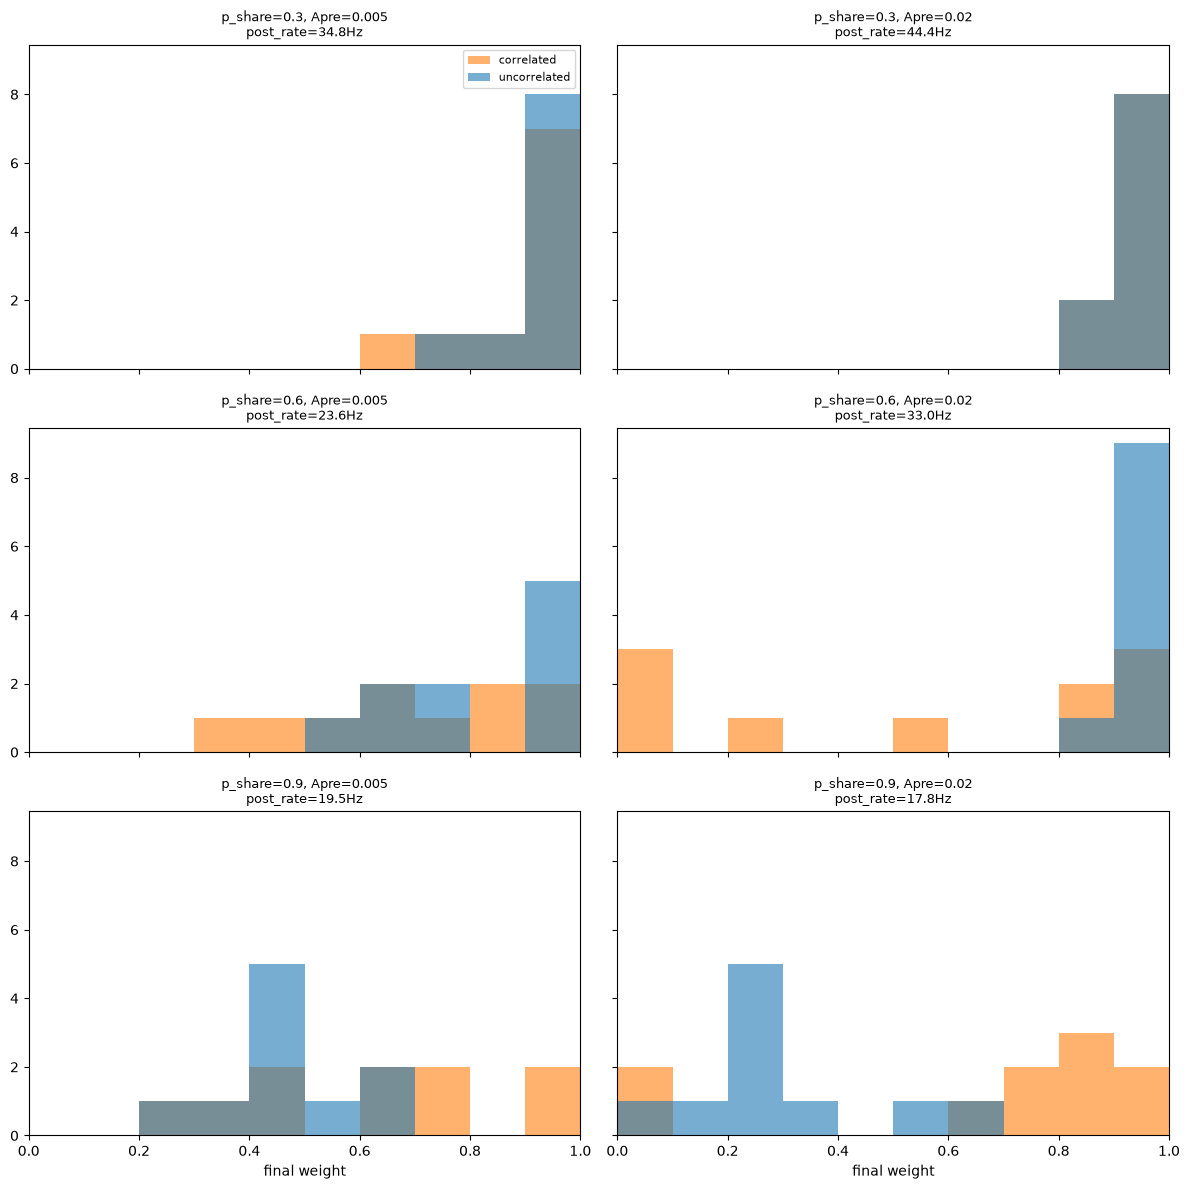

In [8]:
fig, axes = plt.subplots(3, 2, figsize=(12, 12), sharex=True, sharey=True)
for row, p_share in enumerate(p_share_grid):
    for col, Apre_val in enumerate(Apre_grid):
        ax = axes[row, col]
        res = results[(p_share, Apre_val)]
        ax.hist(res['corr_w'], bins=np.linspace(0, 1, 11), alpha=0.6, label='correlated', color='tab:orange')
        ax.hist(res['uncorr_w'], bins=np.linspace(0, 1, 11), alpha=0.6, label='uncorrelated', color='tab:blue')
        ax.set_title(f"p_share={p_share}, Apre={Apre_val}\npost_rate={res['post_rate']:.1f}Hz", fontsize=9)
        ax.set_xlim(0, 1)
        if row == 0 and col == 0:
            ax.legend(fontsize=8)
axes[-1, 0].set_xlabel('final weight')
axes[-1, 1].set_xlabel('final weight')
plt.tight_layout()
plt.savefig('stdp_weight_histograms.png', dpi=100)
plt.show()

## Weight trajectories over time (not just final snapshot) for the two extremes: p_share=0.3 vs p_share=0.9, both at Apre=0.02

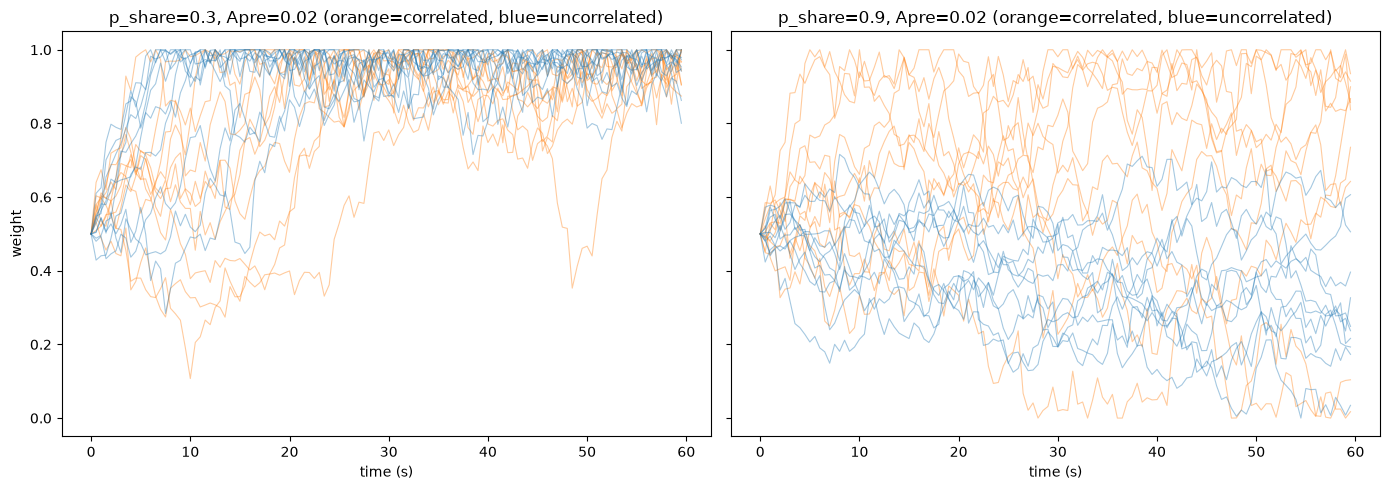

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, p_share in zip(axes, [0.3, 0.9]):
    res = results[(p_share, 0.02)]
    trace = res['weight_trace']
    t_trace = res['trace_t']
    for i in range(10):
        ax.plot(t_trace, trace[i], color='tab:orange', alpha=0.4, linewidth=0.8)
    for i in range(10, 20):
        ax.plot(t_trace, trace[i], color='tab:blue', alpha=0.4, linewidth=0.8)
    ax.set_title(f'p_share={p_share}, Apre=0.02 (orange=correlated, blue=uncorrelated)')
    ax.set_xlabel('time (s)')
axes[0].set_ylabel('weight')
plt.tight_layout()
plt.savefig('stdp_weight_trajectories.png', dpi=100)
plt.show()

## Secondary pattern noticed in the sweep table, worth checking directly: does the
uncorrelated group's final weight systematically decrease as p_share increases?

Not part of the original falsification criteria, but a clear pattern in the raw numbers
worth verifying isn't noise before writing the verdict.

In [10]:
print(f"{'p_share':>8} {'Apre':>7} {'corr_w mean':>12} {'uncorr_w mean':>14} {'diff (corr-uncorr)':>20} {'post_rate':>10}")
for p_share in p_share_grid:
    for Apre_val in Apre_grid:
        res = results[(p_share, Apre_val)]
        diff = res['corr_w'].mean() - res['uncorr_w'].mean()
        print(f"{p_share:>8} {Apre_val:>7} {res['corr_w'].mean():>12.3f} {res['uncorr_w'].mean():>14.3f} "
              f"{diff:>20.3f} {res['post_rate']:>10.1f}")

 p_share    Apre  corr_w mean  uncorr_w mean   diff (corr-uncorr)  post_rate
     0.3   0.005        0.915          0.947               -0.032       34.8
     0.3    0.02        0.941          0.943               -0.003       44.4
     0.6   0.005        0.691          0.824               -0.133       23.6
     0.6    0.02        0.550          0.954               -0.404       33.0
     0.9   0.005        0.625          0.458                0.167       19.5
     0.9    0.02        0.663          0.292                0.370       17.8


## Verdict — neither of the two stated failure modes cleanly, and not the clean "real result"
either: a genuine mix, with a clear underlying mechanism

**What actually happened:** at low-to-medium correlation strength (`p_share=0.3`, and
partially `0.6`), **Failure Mode 1 (runaway) dominates** — nearly all synapses in *both*
groups shoot up to the weight ceiling within the first 5-10 seconds of simulated time
(visible directly in the trajectory plot), before any correlation-driven differentiation has
time to develop. At `p_share=0.3, Apre=0.02`, all 20 synapses end up in the top bin
(0.9-1.0) — total, undifferentiated saturation.

Only at the **highest tested correlation strength (`p_share=0.9`)** does the hypothesized
"real result" emerge: correlated group's weights trend up (final mean 0.625-0.663),
uncorrelated group's trend down (final mean 0.458-0.292) — visible in both the final
histograms (real, if imperfect, bimodal-ish separation) and the trajectory plot (ongoing
divergent drift over the full 60s window, not yet fully converged — this may still be
under-run for a fully settled result).

**A secondary pattern, not part of the original criteria but clear in the raw numbers:** the
uncorrelated group's final weight decreases monotonically as `p_share` increases
(0.945 avg -> 0.89 avg -> 0.375 avg across the three correlation levels), even though the
uncorrelated group's own statistics never change. Plausible mechanism: as the correlated
group increasingly drives postsynaptic spike timing at higher `p_share`, the uncorrelated
group's spikes become progressively less likely to be optimally pre-before-post relative to
those now-more-structured postsynaptic spikes, so they experience relatively more net
depression — a real competitive effect between the groups, not noise.

**Root cause of the runaway (matches the risk flagged before running):** positive feedback —
higher weight -> more reliable postsynaptic spiking -> more potentiation opportunities for
*all* synapses whose presynaptic spikes precede the now-more-frequent postsynaptic spikes.
Postsynaptic firing rates in every run (17.8-44.4 Hz) came out well above the calibrated
baseline (8.9 Hz under fixed uniform weights) — direct evidence weights climbed enough during
the run to substantially increase postsynaptic excitability, which the `Apost = -Apre*1.05`
depression bias (a fixed 5% asymmetry) isn't strong enough to counteract once the rate itself
starts climbing. This is the same shape of failure as the `w_char` lock-in from the Hopfield
work, now confirmed in a structurally different mechanism (STDP synaptic weights vs. Hopfield
basin strength).

**Not adjusting parameters to chase a cleaner result** — this is exactly the pre-registered
6-run grid, reported as it came out. The genuine positive signal at `p_share=0.9` combined
with the clear runaway mechanism at lower `p_share` is real information: the correlation
signal *can* win, but only when strong enough to outcompete a runway that currently dominates
most of the tested parameter space. Flagging for discussion rather than deciding unilaterally
whether the next step is a homeostatic/normalization mechanism (weight-dependent STDP, or
explicit synaptic scaling) to damp the runway, or simply a stronger correlation regime and
longer runtime to let differentiation win before saturation sets in.